# 🏦 Loan Eligibility Prediction 
**Dataset:**  Loan Dataset (2000 records, 13 features)  
**Goal:** Explore, visualise, and predict loan approval using multiple ML classifiers  
---

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# Output folder for saved images
os.makedirs('loan_viz_output', exist_ok=True)
print("✅ All libraries loaded. Images will be saved to ./loan_viz_output/")


✅ All libraries loaded. Images will be saved to ./loan_viz_output/


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('C:\\Users\\Samay\\OneDrive\\Documents\\glowlogics_projects\\Loan_Approval_System\\data\\synthetic_loan_dataset.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (2000, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,Male,Yes,3+,Graduate,No,21006,8490.44,211.0,120,0.0,Semiurban,N
1,LP100001,Female,No,2,Graduate,Yes,9667,4436.46,174.0,120,1.0,Semiurban,Y
2,LP100002,Male,No,2,Graduate,No,6690,9187.47,413.2,300,1.0,Semiurban,N
3,LP100003,Male,No,2,Not Graduate,Yes,6075,4403.74,215.1,120,1.0,Semiurban,Y
4,LP100004,Male,No,3+,Graduate,Yes,9227,5487.80,192.7,240,1.0,Urban,Y


In [3]:
df.drop(['Loan_ID'], axis=1, inplace=True)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             2000 non-null   str    
 1   Married            2000 non-null   str    
 2   Dependents         2000 non-null   str    
 3   Education          2000 non-null   str    
 4   Self_Employed      2000 non-null   str    
 5   ApplicantIncome    2000 non-null   int64  
 6   CoapplicantIncome  2000 non-null   float64
 7   LoanAmount         2000 non-null   float64
 8   Loan_Amount_Term   2000 non-null   int64  
 9   Credit_History     2000 non-null   float64
 10  Property_Area      2000 non-null   str    
 11  Loan_Status        2000 non-null   str    
dtypes: float64(3), int64(2), str(7)
memory usage: 243.4 KB


In [4]:
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,13005.645000,5077.294460,275.980100,240.870000,0.794500
std,6761.777569,2880.950528,129.069712,84.837738,0.404168
min,1518.000000,16.010000,50.100000,120.000000,0.000000
25%,7055.250000,2645.625000,168.550000,180.000000,1.000000
50%,12873.500000,5145.610000,276.400000,240.000000,1.000000
75%,18773.750000,7560.615000,387.050000,300.000000,1.000000
max,24995.000000,9997.520000,499.800000,360.000000,1.000000


In [5]:
print("Missing values (%):")
(df.isnull().sum() * 100 / len(df)).round(2)


Missing values (%):


Gender               0.0
Married              0.0
Dependents           0.0
Education            0.0
Self_Employed        0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
LoanAmount           0.0
Loan_Amount_Term     0.0
Credit_History       0.0
Property_Area        0.0
Loan_Status          0.0
dtype: float64

## 3. Univariate Analysis — Categorical Features
Each feature shown as a **count bar** (left) and a **pie chart** (right).

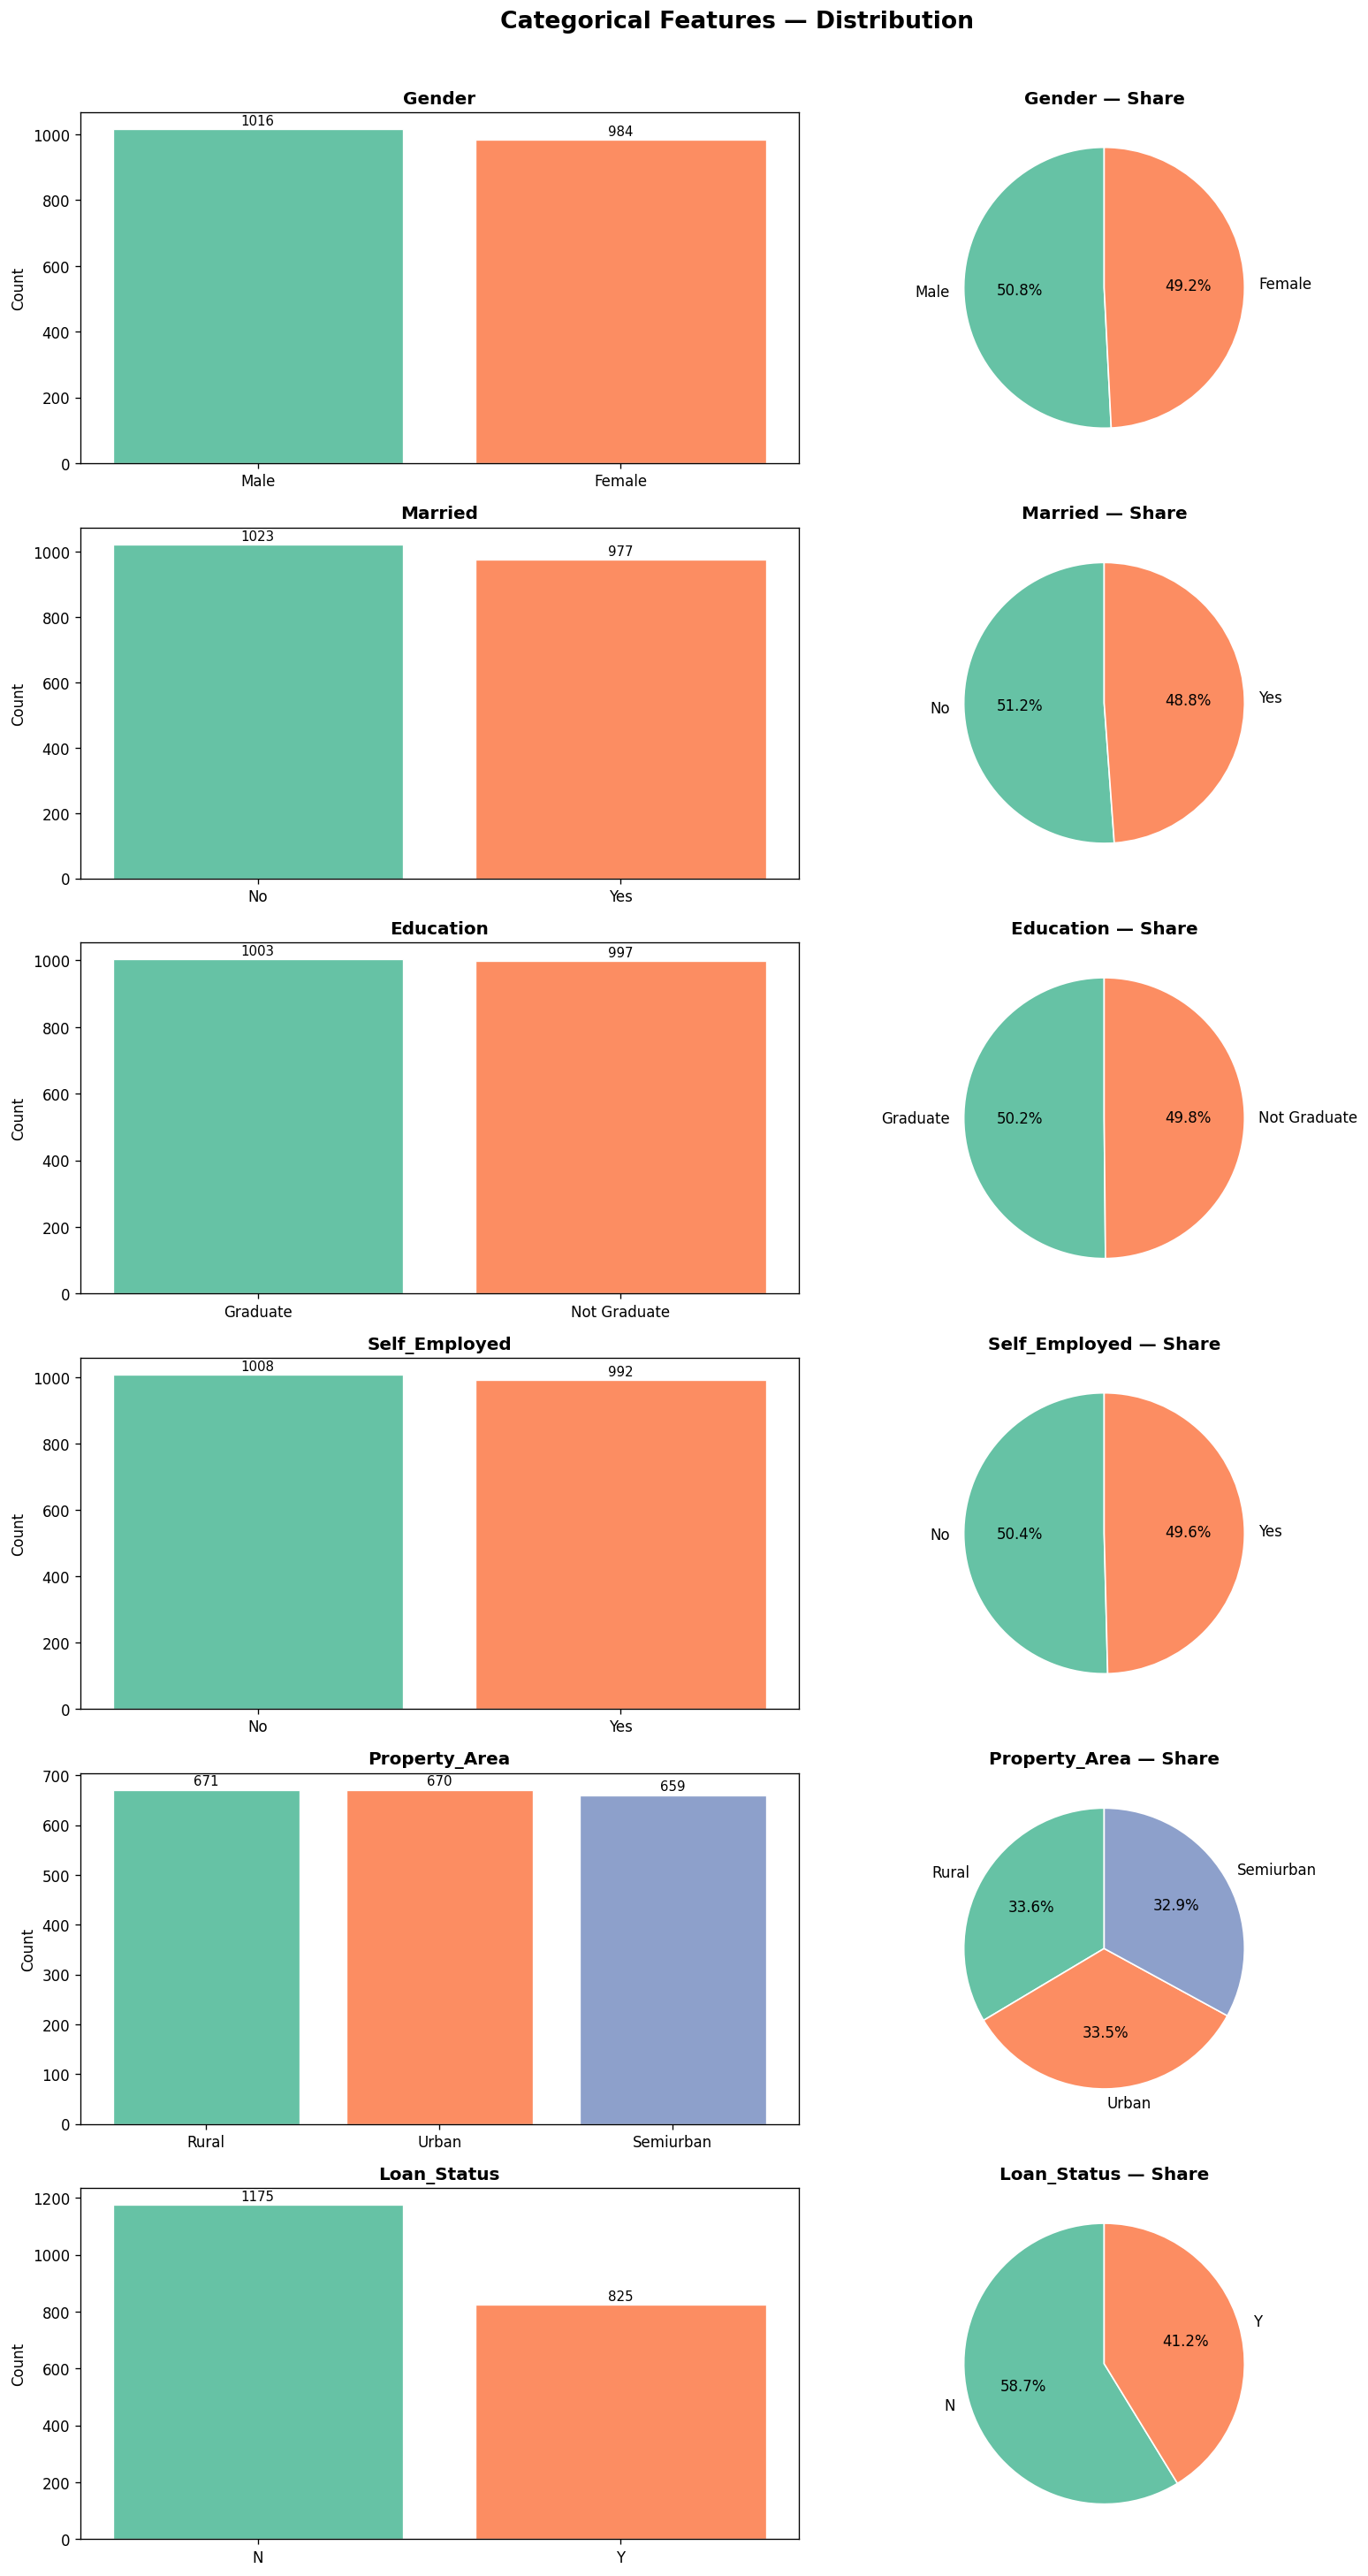

💾 Saved: 01_categorical_distributions.png


In [6]:
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
palette = sns.color_palette("Set2")

fig, axes = plt.subplots(len(cat_cols), 2, figsize=(14, 4 * len(cat_cols)))
fig.suptitle("Categorical Features — Distribution", fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    # Bar
    axes[i, 0].bar(counts.index, counts.values,
                   color=palette[:len(counts)], edgecolor='white', linewidth=0.8)
    axes[i, 0].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Count')
    for bar, val in zip(axes[i, 0].patches, counts.values):
        axes[i, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                        str(val), ha='center', va='bottom', fontsize=9)
    # Pie
    axes[i, 1].pie(counts, labels=counts.index, autopct='%1.1f%%',
                   colors=palette[:len(counts)], startangle=90,
                   wedgeprops=dict(edgecolor='white'))
    axes[i, 1].set_title(f'{col} — Share', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('loan_viz_output/01_categorical_distributions.png')
plt.show()
print("💾 Saved: 01_categorical_distributions.png")


## 4. Univariate Analysis — Numerical Features
Histograms with KDE curves for income, loan amount, and term.

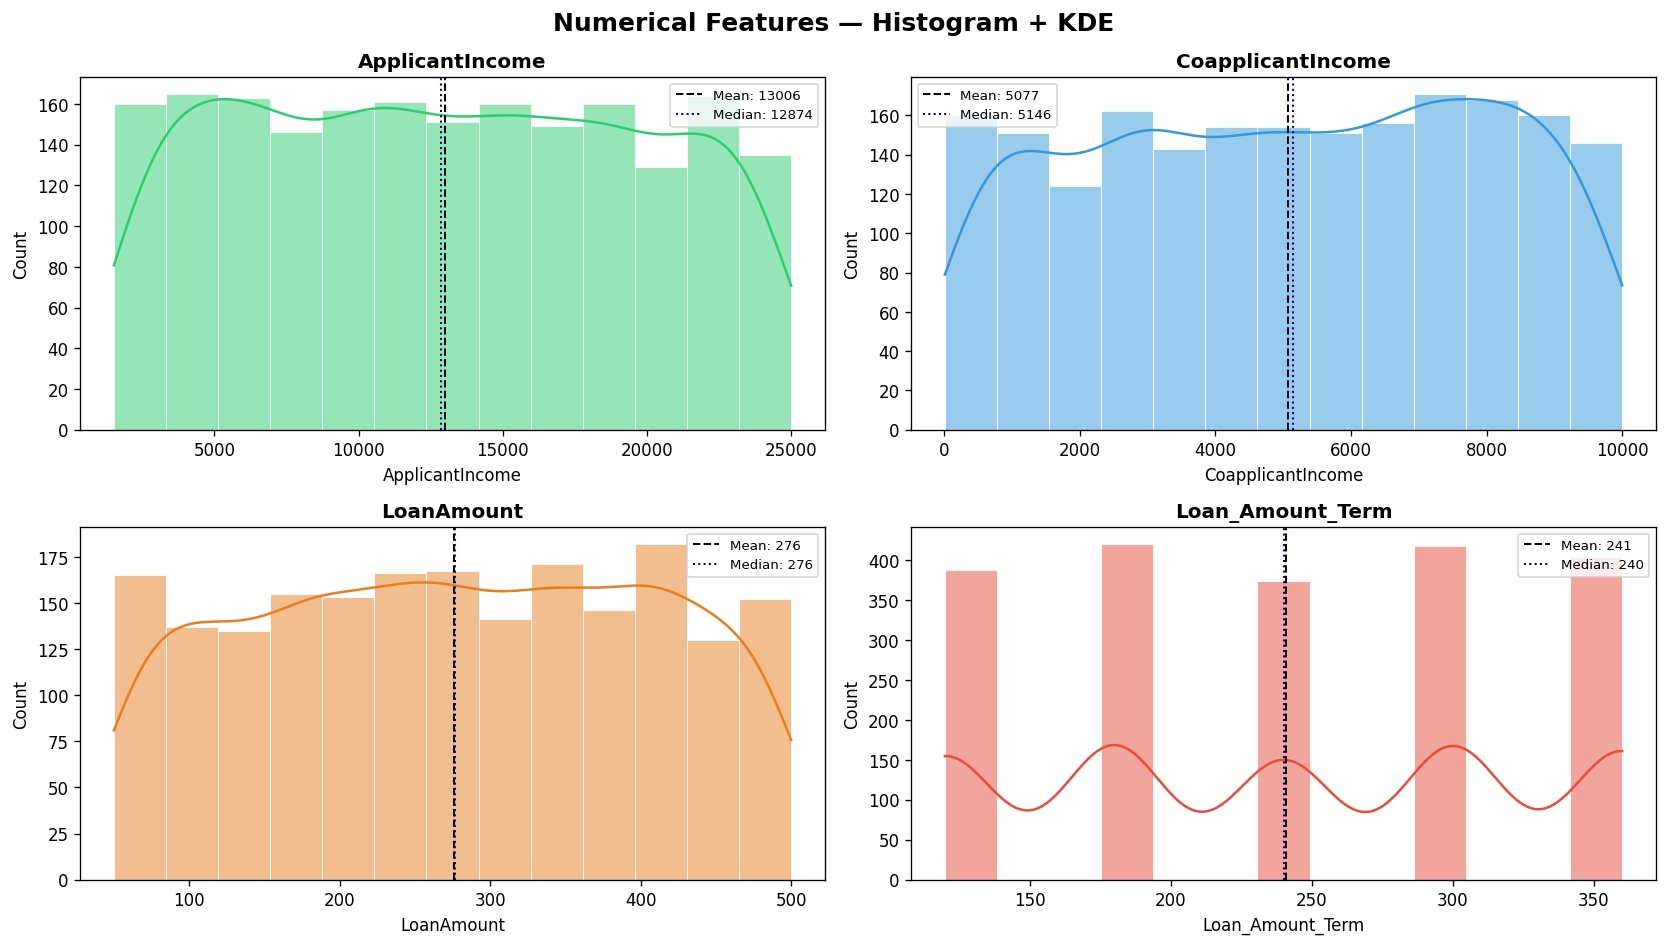

💾 Saved: 02_numerical_distributions.png


In [7]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
colors   = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
fig.suptitle("Numerical Features — Histogram + KDE", fontsize=15, fontweight='bold')

for ax, col, c in zip(axes, num_cols, colors):
    sns.histplot(df[col], kde=True, ax=ax, color=c, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(),   color='black', linestyle='--', linewidth=1.2, label=f'Mean: {df[col].mean():.0f}')
    ax.axvline(df[col].median(), color='navy',  linestyle=':',  linewidth=1.2, label=f'Median: {df[col].median():.0f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('loan_viz_output/02_numerical_distributions.png')
plt.show()
print("💾 Saved: 02_numerical_distributions.png")


## 5. Loan Approval Rate by Key Categories
Stacked percentage bars reveal approval patterns across demographic and financial groups.

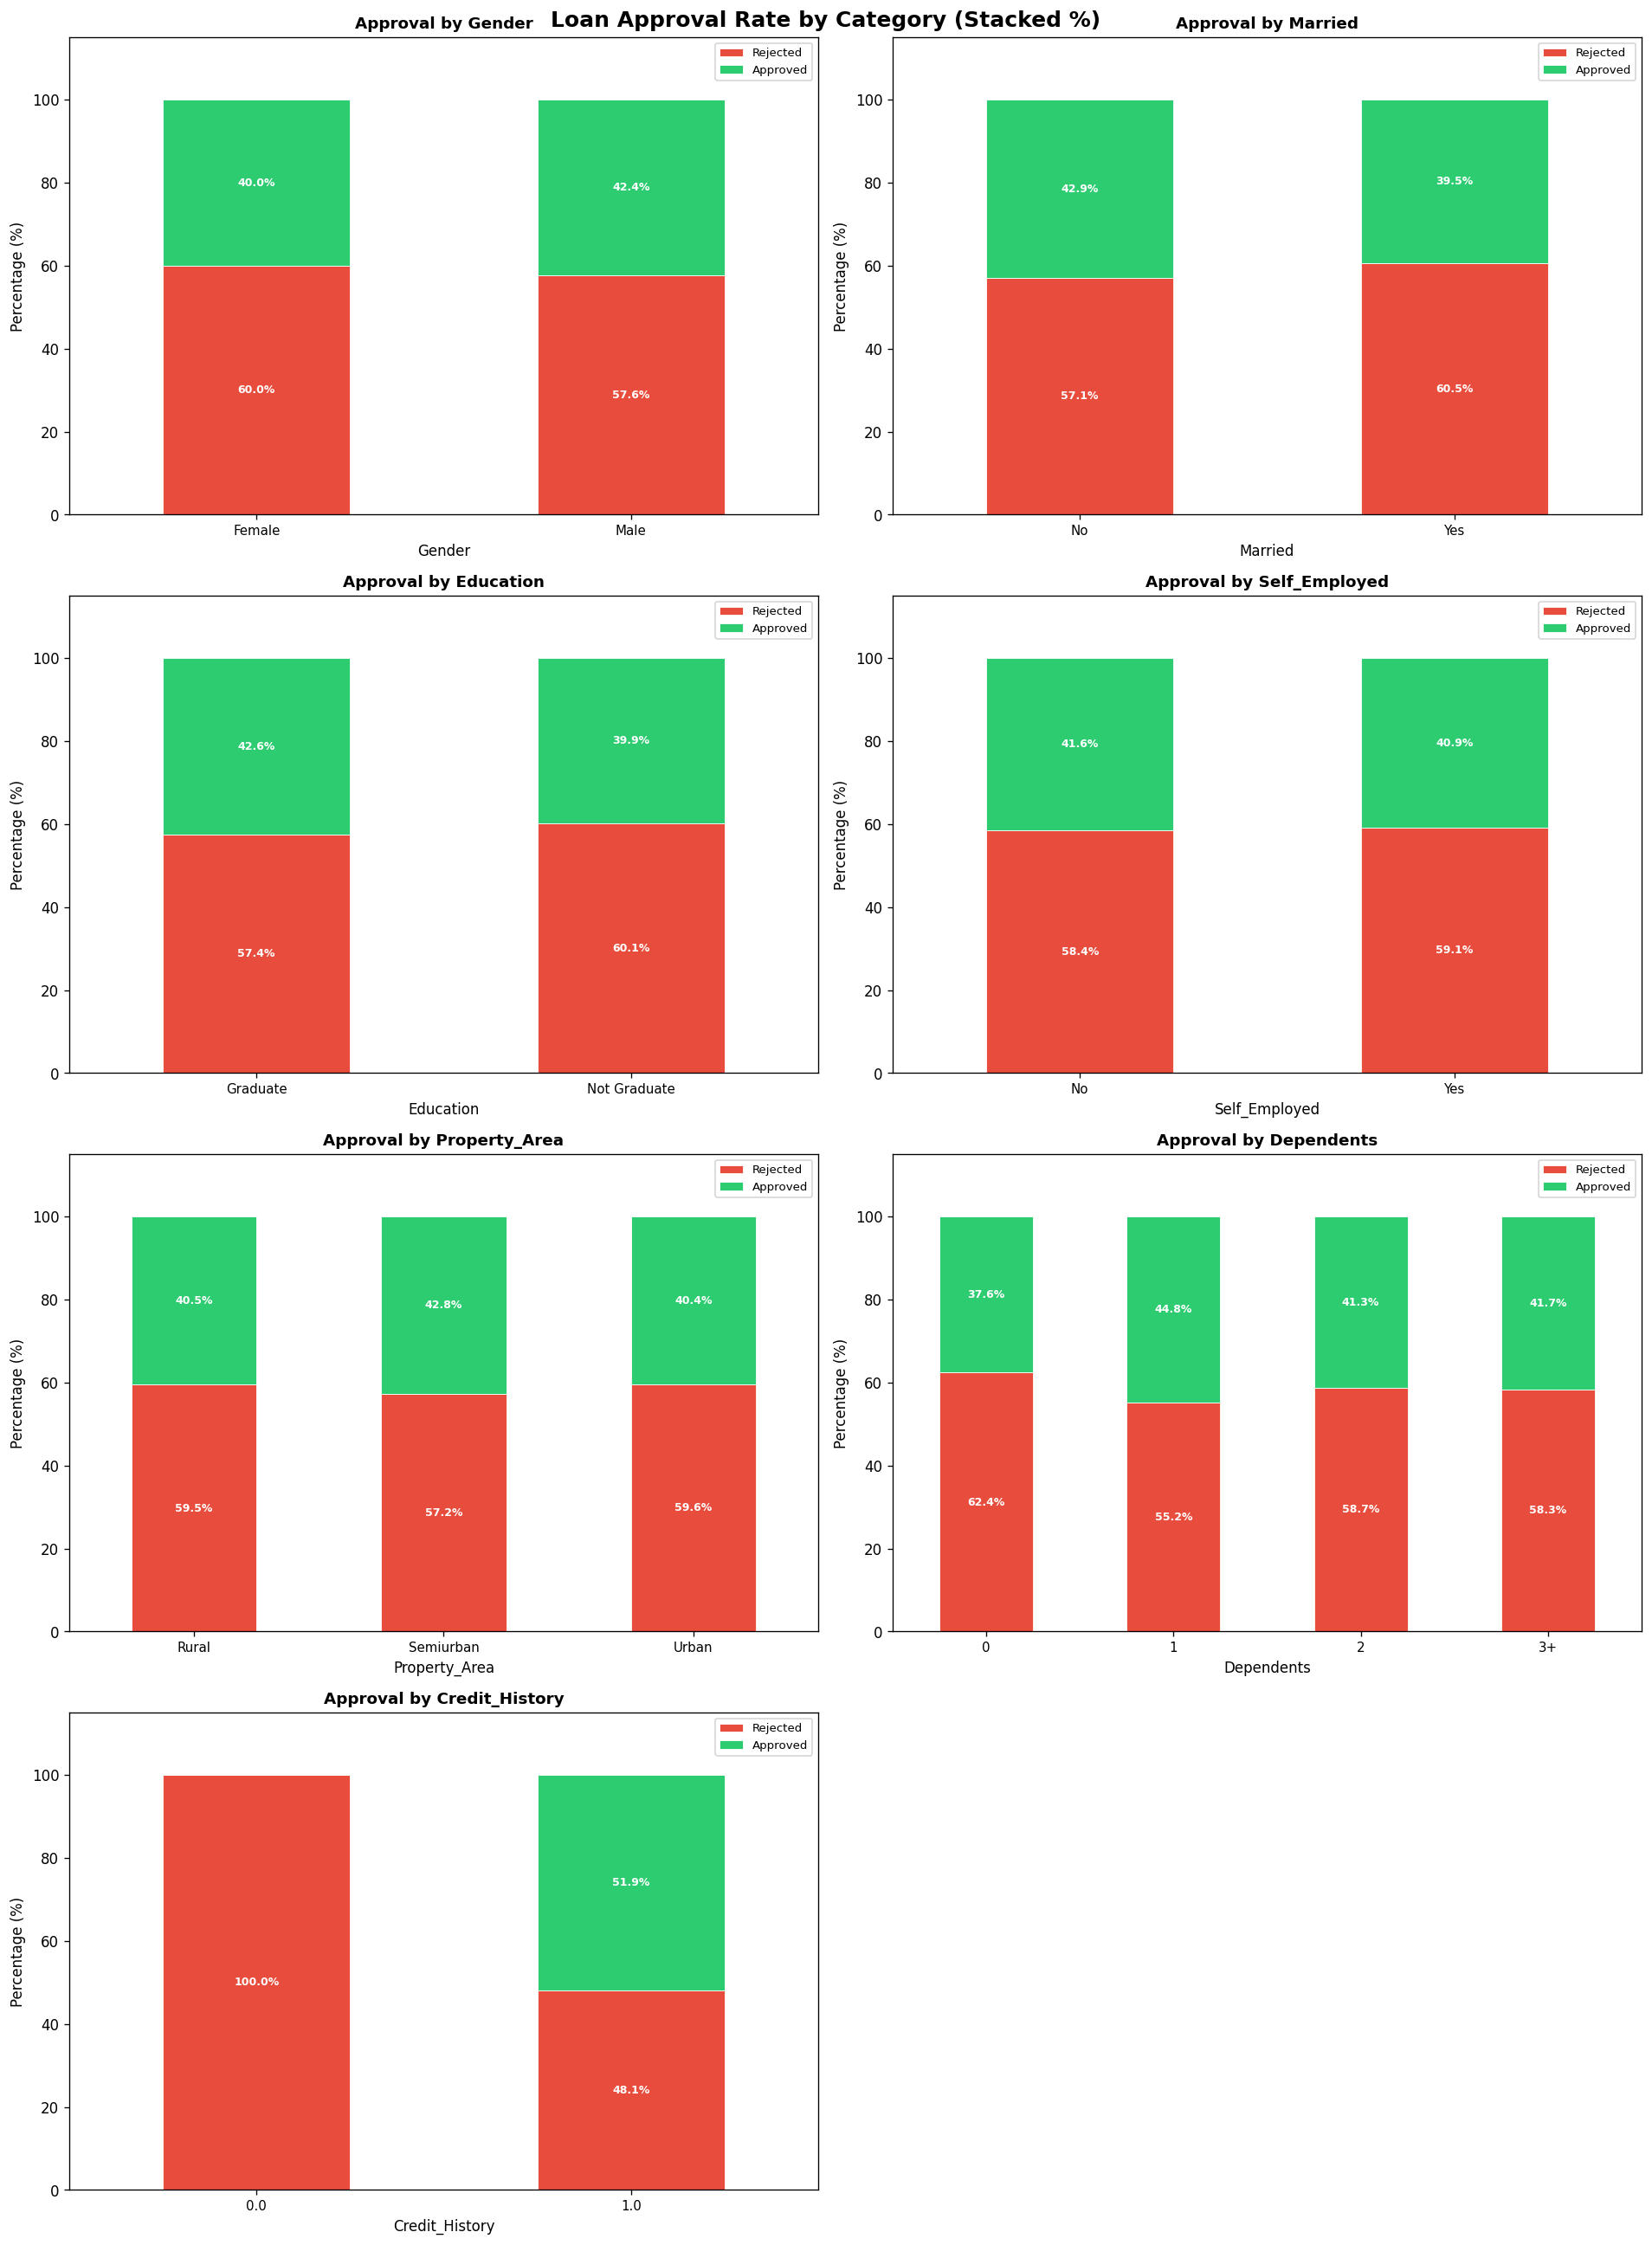

💾 Saved: 03_approval_by_category.png


In [8]:
group_cols = ['Gender', 'Married', 'Education', 'Self_Employed',
              'Property_Area', 'Dependents', 'Credit_History']

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()
fig.suptitle("Loan Approval Rate by Category (Stacked %)", fontsize=15, fontweight='bold')

colors_bar = {'N': '#e74c3c', 'Y': '#2ecc71'}

for ax, col in zip(axes, group_cols):
    ct = pd.crosstab(df[col], df['Loan_Status'], normalize='index') * 100
    ct[['N', 'Y']].plot(kind='bar', stacked=True, ax=ax,
                        color=[colors_bar['N'], colors_bar['Y']],
                        edgecolor='white', linewidth=0.5)
    ax.set_title(f'Approval by {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel(col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
    ax.legend(['Rejected', 'Approved'], loc='upper right', fontsize=8)
    ax.set_ylim(0, 115)
    for bar in ax.patches:
        height = bar.get_height()
        if height > 5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + height/2,
                    f'{height:.1f}%', ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold')

# hide empty subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('loan_viz_output/03_approval_by_category.png')
plt.show()
print("💾 Saved: 03_approval_by_category.png")


## 6. Applicant Income vs Loan Amount (coloured by Approval)

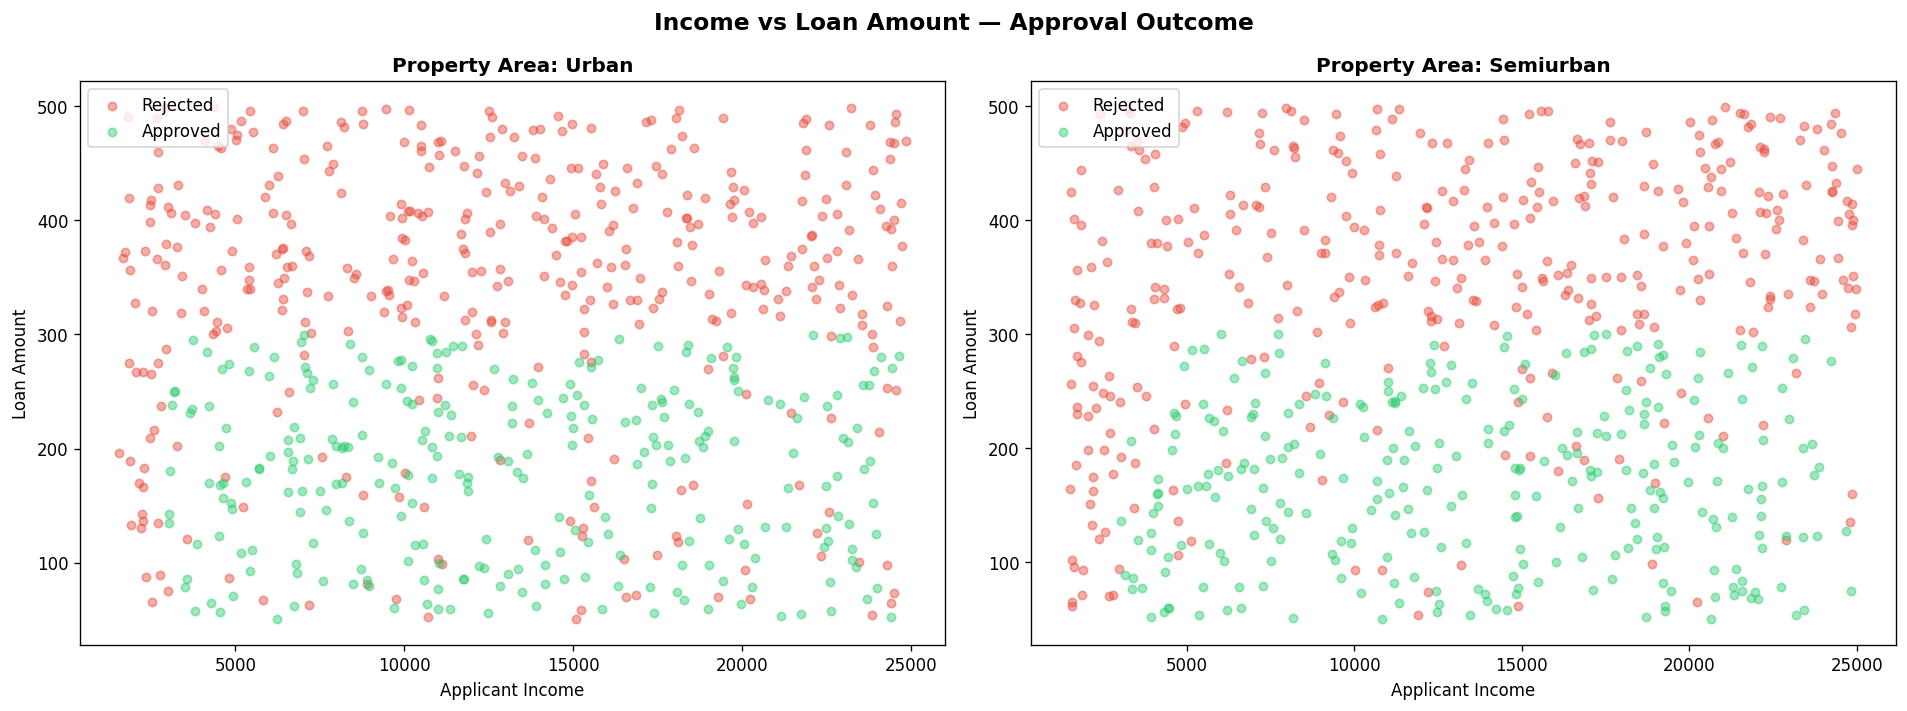

💾 Saved: 04_income_vs_loanamount_scatter.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Income vs Loan Amount — Approval Outcome", fontsize=14, fontweight='bold')

color_map = {'Y': '#2ecc71', 'N': '#e74c3c'}

for ax, prop_area in zip(axes, ['Urban', 'Semiurban']):
    sub = df[df['Property_Area'] == prop_area]
    for status, grp in sub.groupby('Loan_Status'):
        ax.scatter(grp['ApplicantIncome'], grp['LoanAmount'],
                   c=color_map[status], alpha=0.45, s=25,
                   label='Approved' if status == 'Y' else 'Rejected')
    ax.set_title(f'Property Area: {prop_area}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Applicant Income')
    ax.set_ylabel('Loan Amount')
    ax.legend()

plt.tight_layout()
plt.savefig('loan_viz_output/04_income_vs_loanamount_scatter.png')
plt.show()
print("💾 Saved: 04_income_vs_loanamount_scatter.png")


## 7. Numerical Features vs Loan Status — Box Plots

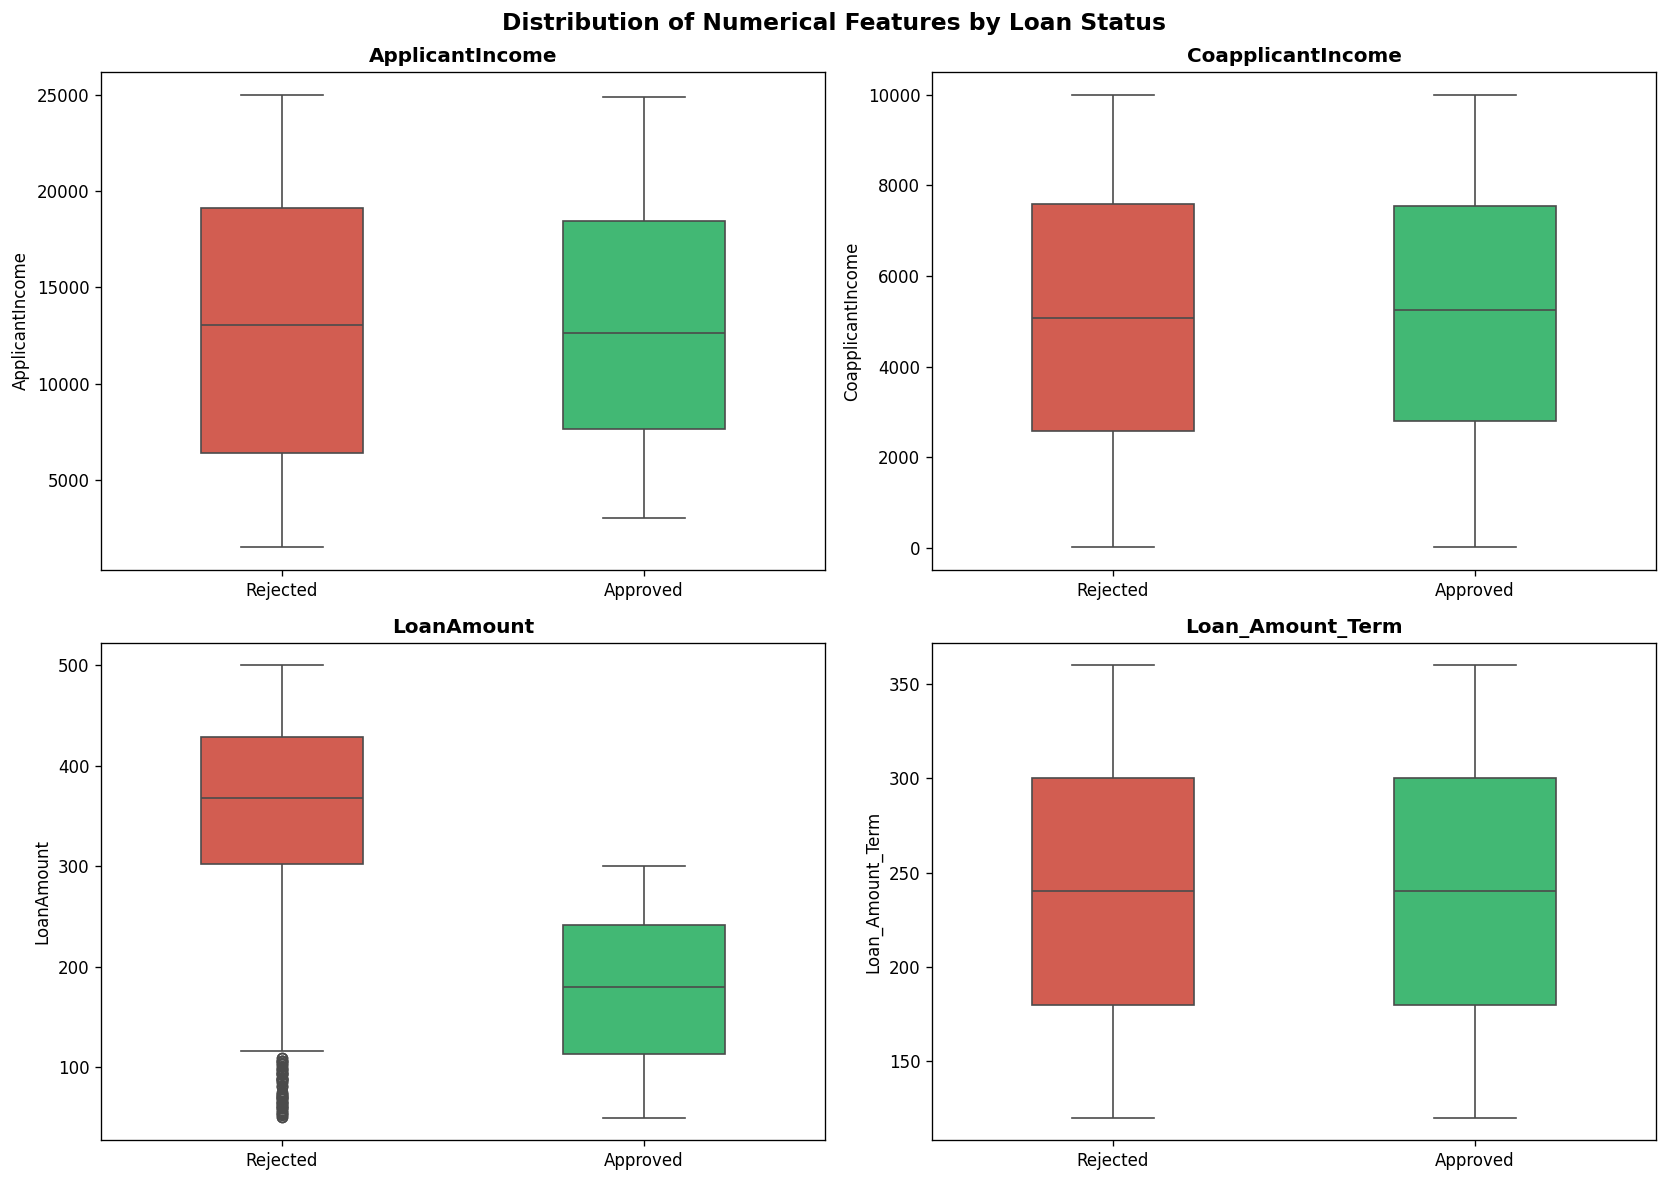

💾 Saved: 05_boxplots_by_loan_status.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
fig.suptitle("Distribution of Numerical Features by Loan Status", fontsize=14, fontweight='bold')

pal = {'N': '#e74c3c', 'Y': '#2ecc71'}

for ax, col in zip(axes, ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']):
    sns.boxplot(x='Loan_Status', y=col, data=df, palette=pal, ax=ax,
                order=['N', 'Y'], width=0.45)
    ax.set_xticklabels(['Rejected', 'Approved'])
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('loan_viz_output/05_boxplots_by_loan_status.png')
plt.show()
print("💾 Saved: 05_boxplots_by_loan_status.png")


## 8. Violin Plots — Income Distribution by Gender & Approval

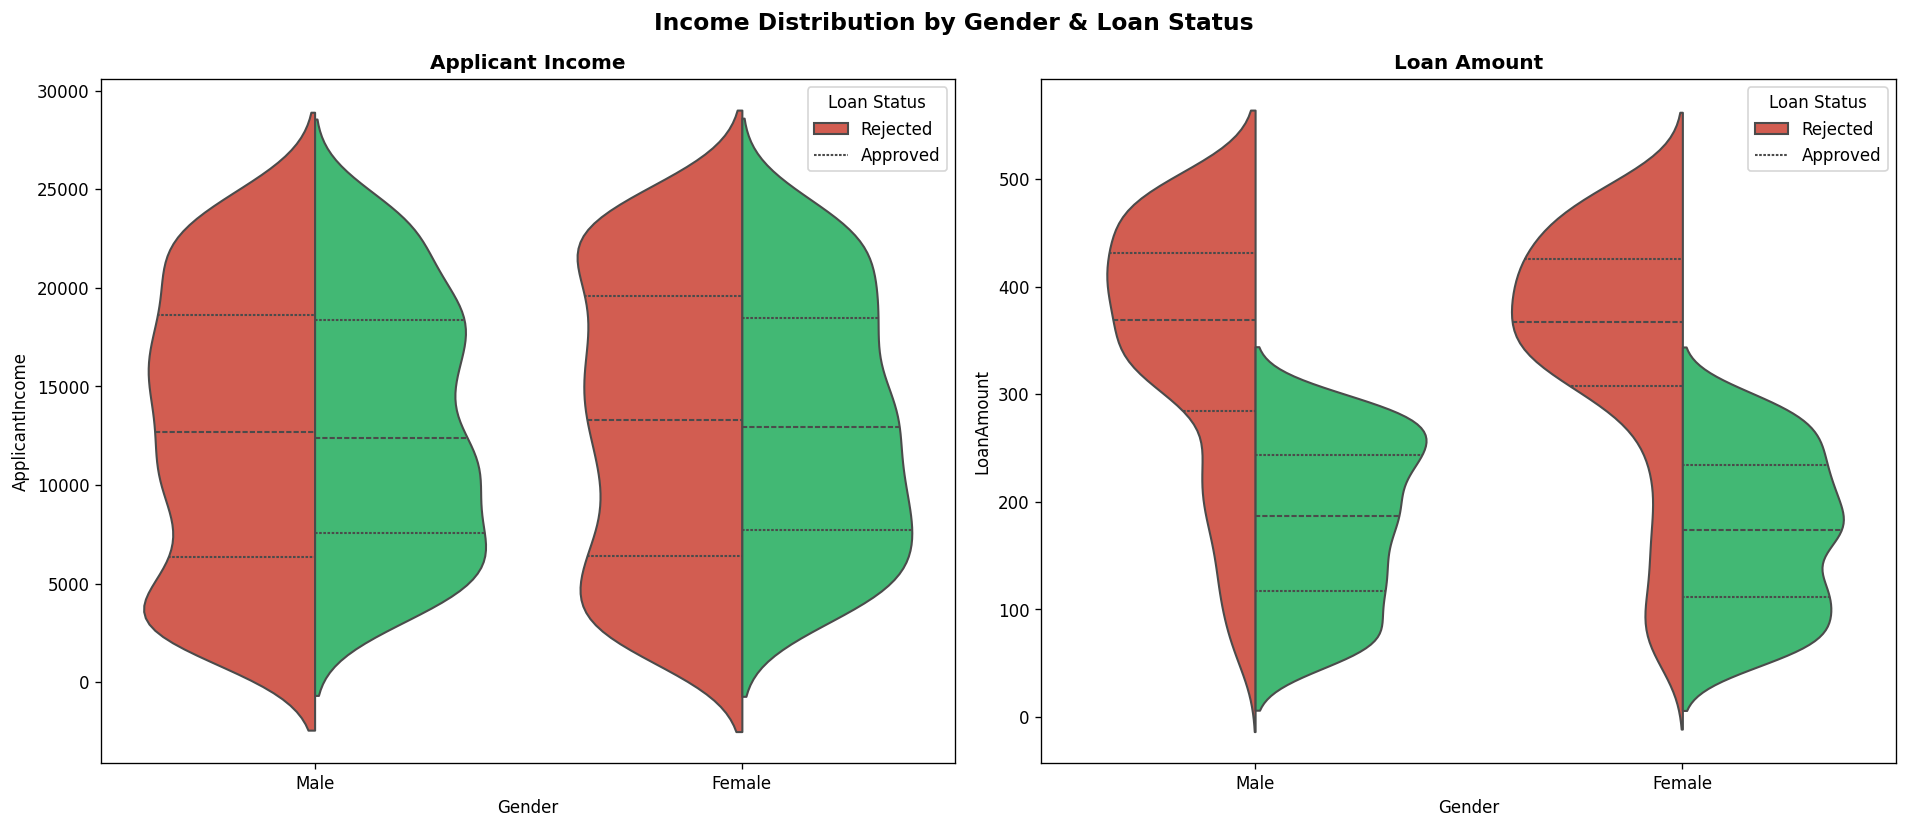

💾 Saved: 06_violin_income_gender.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Income Distribution by Gender & Loan Status", fontsize=14, fontweight='bold')

sns.violinplot(x='Gender', y='ApplicantIncome', hue='Loan_Status',
               data=df, palette={'N': '#e74c3c', 'Y': '#2ecc71'},
               split=True, inner='quart', ax=axes[0])
axes[0].set_title("Applicant Income", fontweight='bold')
axes[0].legend(title='Loan Status', labels=['Rejected', 'Approved'])

sns.violinplot(x='Gender', y='LoanAmount', hue='Loan_Status',
               data=df, palette={'N': '#e74c3c', 'Y': '#2ecc71'},
               split=True, inner='quart', ax=axes[1])
axes[1].set_title("Loan Amount", fontweight='bold')
axes[1].legend(title='Loan Status', labels=['Rejected', 'Approved'])

plt.tight_layout()
plt.savefig('loan_viz_output/06_violin_income_gender.png')
plt.show()
print("💾 Saved: 06_violin_income_gender.png")


## 9. Correlation Heatmap — Numerical Features

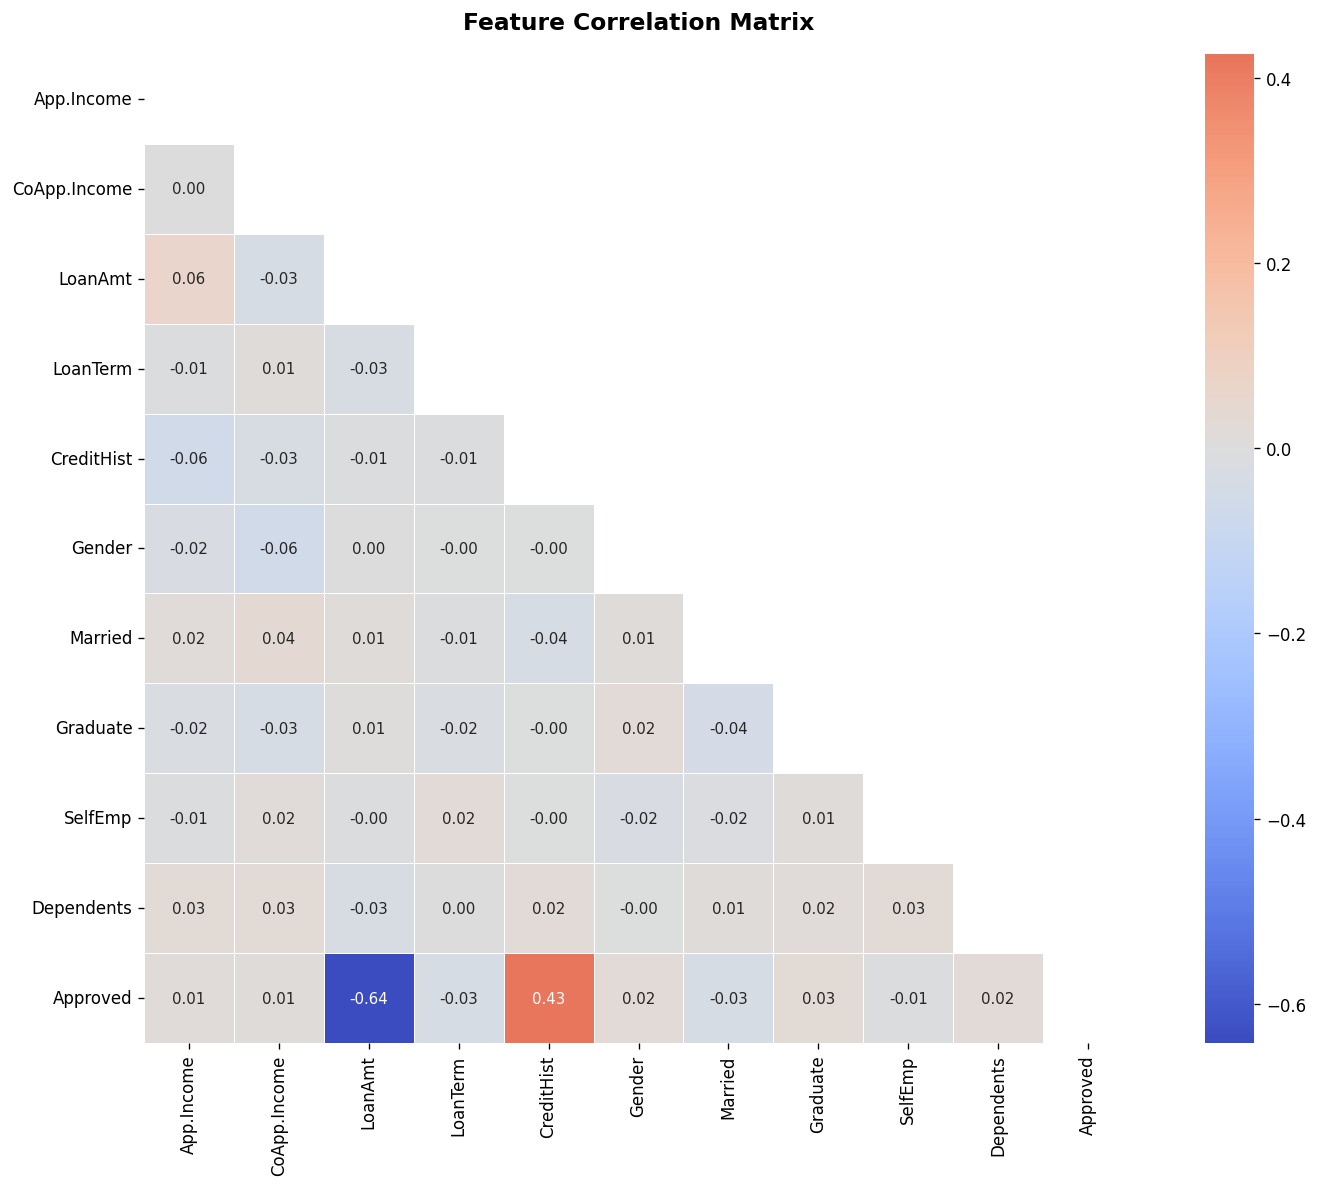

💾 Saved: 07_correlation_heatmap.png


In [12]:
df_enc = df.copy()
df_enc['Loan_Status_enc']  = (df_enc['Loan_Status'] == 'Y').astype(int)
df_enc['Gender_enc']       = (df_enc['Gender'] == 'Male').astype(int)
df_enc['Married_enc']      = (df_enc['Married'] == 'Yes').astype(int)
df_enc['Education_enc']    = (df_enc['Education'] == 'Graduate').astype(int)
df_enc['Self_Employed_enc']= (df_enc['Self_Employed'] == 'Yes').astype(int)
df_enc['Dependents_enc']   = df_enc['Dependents'].replace({'3+': 3}).astype(float)

num_df = df_enc[['ApplicantIncome','CoapplicantIncome','LoanAmount',
                  'Loan_Amount_Term','Credit_History','Gender_enc',
                  'Married_enc','Education_enc','Self_Employed_enc',
                  'Dependents_enc','Loan_Status_enc']]
num_df.columns = ['App.Income','CoApp.Income','LoanAmt','LoanTerm',
                   'CreditHist','Gender','Married','Graduate',
                   'SelfEmp','Dependents','Approved']

matrix = num_df.corr()
mask   = np.triu(np.ones_like(matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(matrix, mask=mask, annot=True, fmt='.2f', center=0,
            cmap='coolwarm', square=True, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('loan_viz_output/07_correlation_heatmap.png')
plt.show()
print("💾 Saved: 07_correlation_heatmap.png")


## 10. Pair Plot — Key Numerical Features vs Loan Status

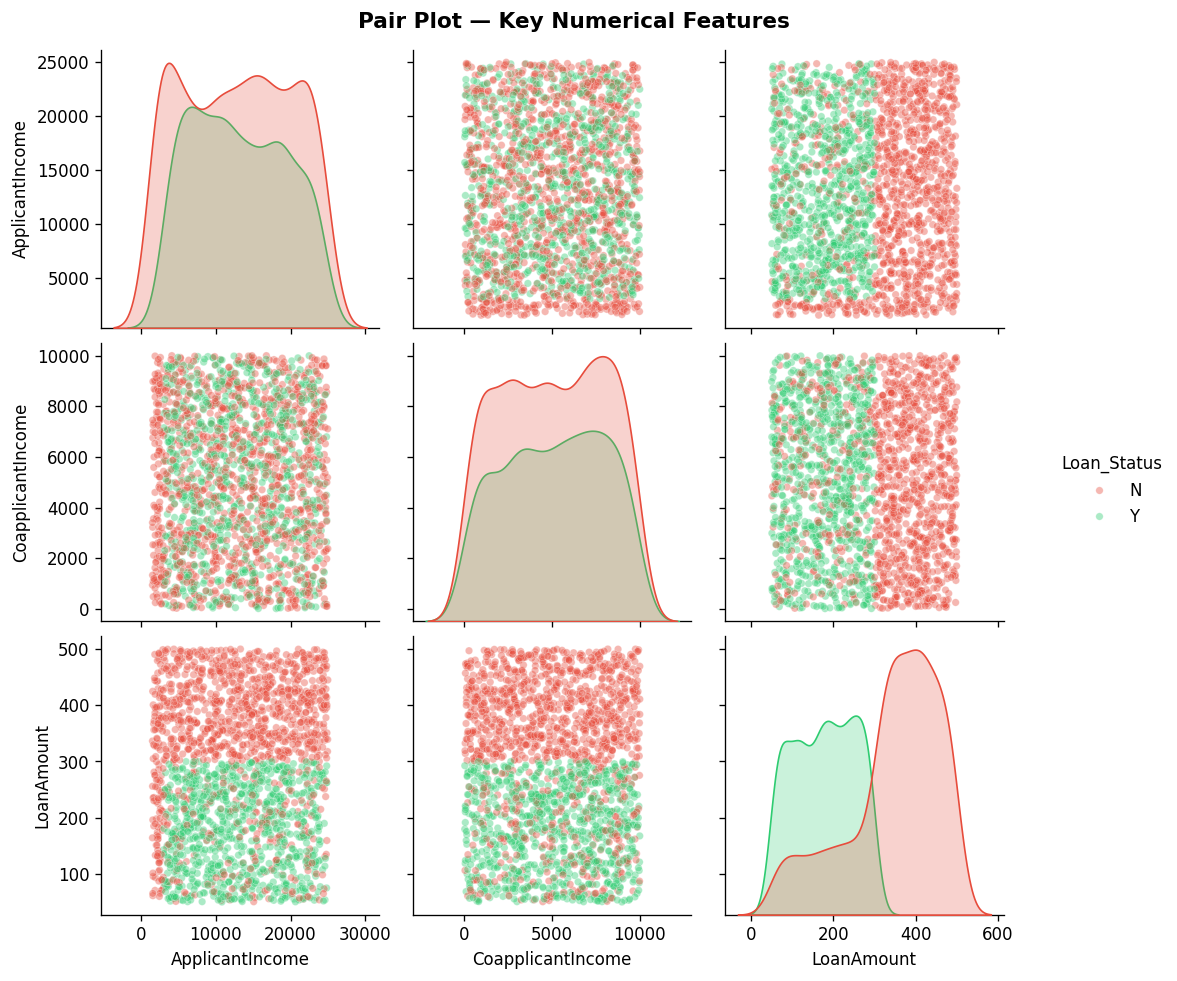

💾 Saved: 08_pairplot.png


In [13]:
pair_df = df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Status']].copy()
g = sns.pairplot(pair_df, hue='Loan_Status',
                 palette={'N': '#e74c3c', 'Y': '#2ecc71'},
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde')
g.fig.suptitle("Pair Plot — Key Numerical Features", y=1.02, fontsize=13, fontweight='bold')
g.fig.set_size_inches(10, 8)
plt.savefig('loan_viz_output/08_pairplot.png')
plt.show()
print("💾 Saved: 08_pairplot.png")


## 11. Credit History — Heatmap by Property Area & Approval

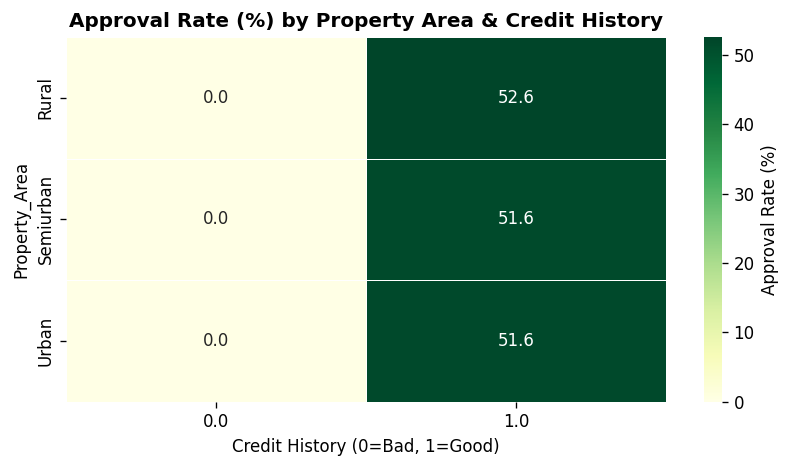

💾 Saved: 09_approval_rate_heatmap.png


In [14]:
pivot = pd.crosstab(df['Property_Area'], df['Credit_History'],
                    values=df['Loan_Status'].map({'Y':1,'N':0}),
                    aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Approval Rate (%)'})
ax.set_title("Approval Rate (%) by Property Area & Credit History",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Credit History (0=Bad, 1=Good)")
plt.tight_layout()
plt.savefig('loan_viz_output/09_approval_rate_heatmap.png')
plt.show()
print("💾 Saved: 09_approval_rate_heatmap.png")


## 12. Loan Amount Buckets — Approval Rate Analysis

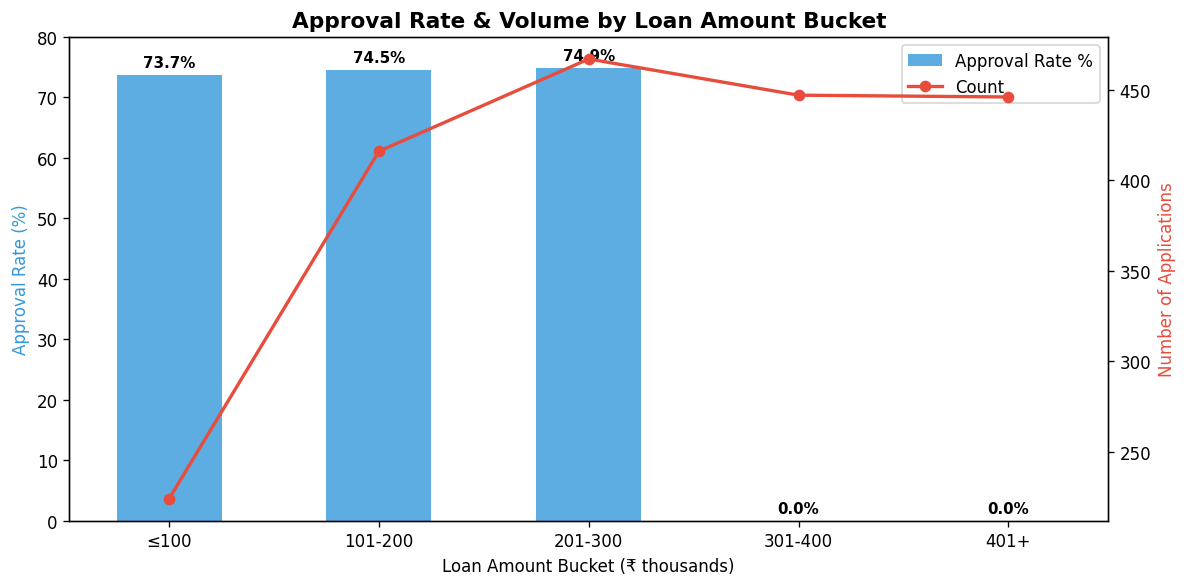

💾 Saved: 10_loan_bucket_approval.png


In [15]:
df2 = df.copy()
df2['LoanBucket'] = pd.cut(df2['LoanAmount'],
                           bins=[0, 100, 200, 300, 400, 500],
                           labels=['≤100', '101-200', '201-300', '301-400', '401+'])

bucket_rate = (df2.groupby('LoanBucket', observed=True)['Loan_Status']
                  .apply(lambda x: (x == 'Y').mean() * 100))
bucket_cnt  = df2.groupby('LoanBucket', observed=True).size()

fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(bucket_rate))
bars = ax1.bar(x, bucket_rate, color='#3498db', alpha=0.8, width=0.5, label='Approval Rate %')
ax1.set_ylabel('Approval Rate (%)', color='#3498db')
ax1.set_xticks(x); ax1.set_xticklabels(bucket_rate.index)
ax1.set_xlabel('Loan Amount Bucket (₹ thousands)')
ax1.set_ylim(0, 80)

ax2 = ax1.twinx()
ax2.plot(x, bucket_cnt.values, color='#e74c3c', marker='o', linewidth=2, label='Count')
ax2.set_ylabel('Number of Applications', color='#e74c3c')

for bar, rate in zip(bars, bucket_rate):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title("Approval Rate & Volume by Loan Amount Bucket", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('loan_viz_output/10_loan_bucket_approval.png')
plt.show()
print("💾 Saved: 10_loan_bucket_approval.png")


## 13. Preprocessing & Feature Engineering
Handle nulls, encode categoricals, scale features, and prepare train/test split.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_ml = df.copy()

# Encode binary categoricals
df_ml['Gender']       = df_ml['Gender'].map({'Male': 1, 'Female': 0})
df_ml['Married']      = df_ml['Married'].map({'Yes': 1, 'No': 0})
df_ml['Education']    = df_ml['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df_ml['Self_Employed']= df_ml['Self_Employed'].map({'Yes': 1, 'No': 0})
df_ml['Loan_Status']  = df_ml['Loan_Status'].map({'Y': 1, 'N': 0})
df_ml['Dependents']   = df_ml['Dependents'].replace({'3+': 3}).astype(float)

# One-hot encode Property_Area
df_ml = pd.get_dummies(df_ml, columns=['Property_Area'], drop_first=True)

# Fill any remaining nulls
for col in df_ml.select_dtypes(include='float').columns:
    df_ml[col].fillna(df_ml[col].median(), inplace=True)

print("Processed shape:", df_ml.shape)
df_ml.head()


Processed shape: (2000, 13)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,1,3.0,1,0,21006,8490.44,211.0,120,0.0,0,True,False
1,0,0,2.0,1,1,9667,4436.46,174.0,120,1.0,1,True,False
2,1,0,2.0,1,0,6690,9187.47,413.2,300,1.0,0,True,False
3,1,0,2.0,0,1,6075,4403.74,215.1,120,1.0,1,True,False
4,1,0,3.0,1,1,9227,5487.80,192.7,240,1.0,1,False,True


In [17]:
X = df_ml.drop('Loan_Status', axis=1)
y = df_ml['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")
print(f"Class balance (train): {pd.Series(y_train).value_counts().to_dict()}")


Train: (1600, 12)  |  Test: (400, 12)
Class balance (train): {0: 940, 1: 660}


## 14. Train Multiple Classifiers

In [18]:
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                      f1_score, roc_auc_score, confusion_matrix,
                                      classification_report, roc_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes'         : GaussianNB(),
}

results = []
trained_models = {}

for name, clf in models.items():
    clf.fit(X_train_sc, y_train)
    y_pred  = clf.predict(X_test_sc)
    y_proba = clf.predict_proba(X_test_sc)[:, 1] if hasattr(clf, 'predict_proba') else None
    
    cv_f1 = cross_val_score(clf, X_train_sc, y_train, cv=5, scoring='f1').mean()
    
    results.append({
        'Model'         : name,
        'Train Acc'     : round(clf.score(X_train_sc, y_train) * 100, 2),
        'Test Acc'      : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision'     : round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'        : round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score'      : round(f1_score(y_test, y_pred) * 100, 2),
        'CV F1 (mean)'  : round(cv_f1 * 100, 2),
        'ROC-AUC'       : round(roc_auc_score(y_test, y_proba) * 100, 2) if y_proba is not None else 'N/A',
    })
    trained_models[name] = (clf, y_pred, y_proba)

results_df = pd.DataFrame(results).sort_values('Test Acc', ascending=False)
results_df


,Model,Train Acc,Test Acc,Precision,Recall,F1 Score,CV F1 (mean),ROC-AUC
1,Decision Tree,100.00,100.0,100.00,100.00,100.00,99.77,100.00
2,Random Forest,100.00,100.0,100.00,100.00,100.00,99.70,100.00
3,Gradient Boosting,100.00,100.0,100.00,100.00,100.00,99.77,100.00
4,AdaBoost,100.00,100.0,100.00,100.00,100.00,99.70,100.00
0,Logistic Regression,94.38,93.5,88.83,96.36,92.44,93.06,97.53
5,KNN,92.31,89.0,81.35,95.15,87.71,86.15,95.65
6,Naive Bayes,62.12,60.5,51.08,100.00,67.62,68.54,97.18


## 15. Model Comparison — Visual Scorecard

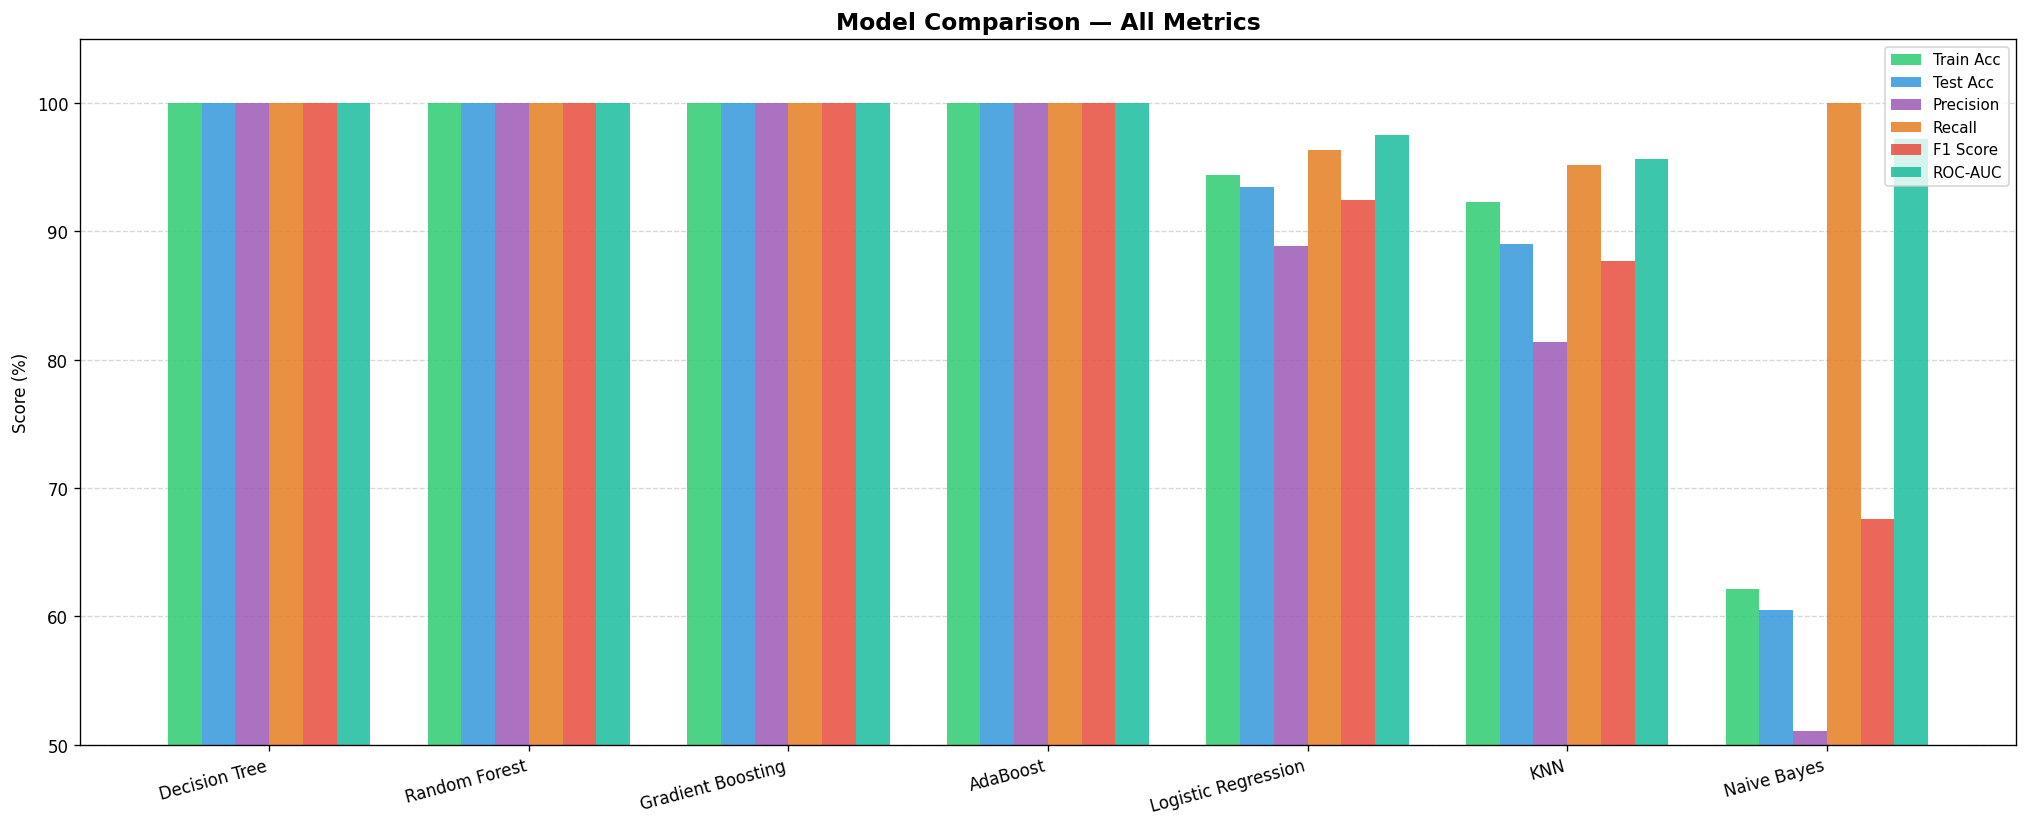

💾 Saved: 11_model_comparison_bar.png


In [19]:
metrics = ['Train Acc', 'Test Acc', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
plot_df = results_df[results_df['ROC-AUC'] != 'N/A'].copy()
plot_df[metrics] = plot_df[metrics].astype(float)

x = np.arange(len(plot_df))
width = 0.13
fig, ax = plt.subplots(figsize=(17, 7))

colors_met = ['#2ecc71','#3498db','#9b59b6','#e67e22','#e74c3c','#1abc9c']
for i, (met, col) in enumerate(zip(metrics, colors_met)):
    bars = ax.bar(x + i * width, plot_df[met], width, label=met, color=col, alpha=0.85)

ax.set_xticks(x + width * (len(metrics) - 1) / 2)
ax.set_xticklabels(plot_df['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(50, 105)
ax.set_title("Model Comparison — All Metrics", fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('loan_viz_output/11_model_comparison_bar.png')
plt.show()
print("💾 Saved: 11_model_comparison_bar.png")


## 16. ROC Curves — All Models

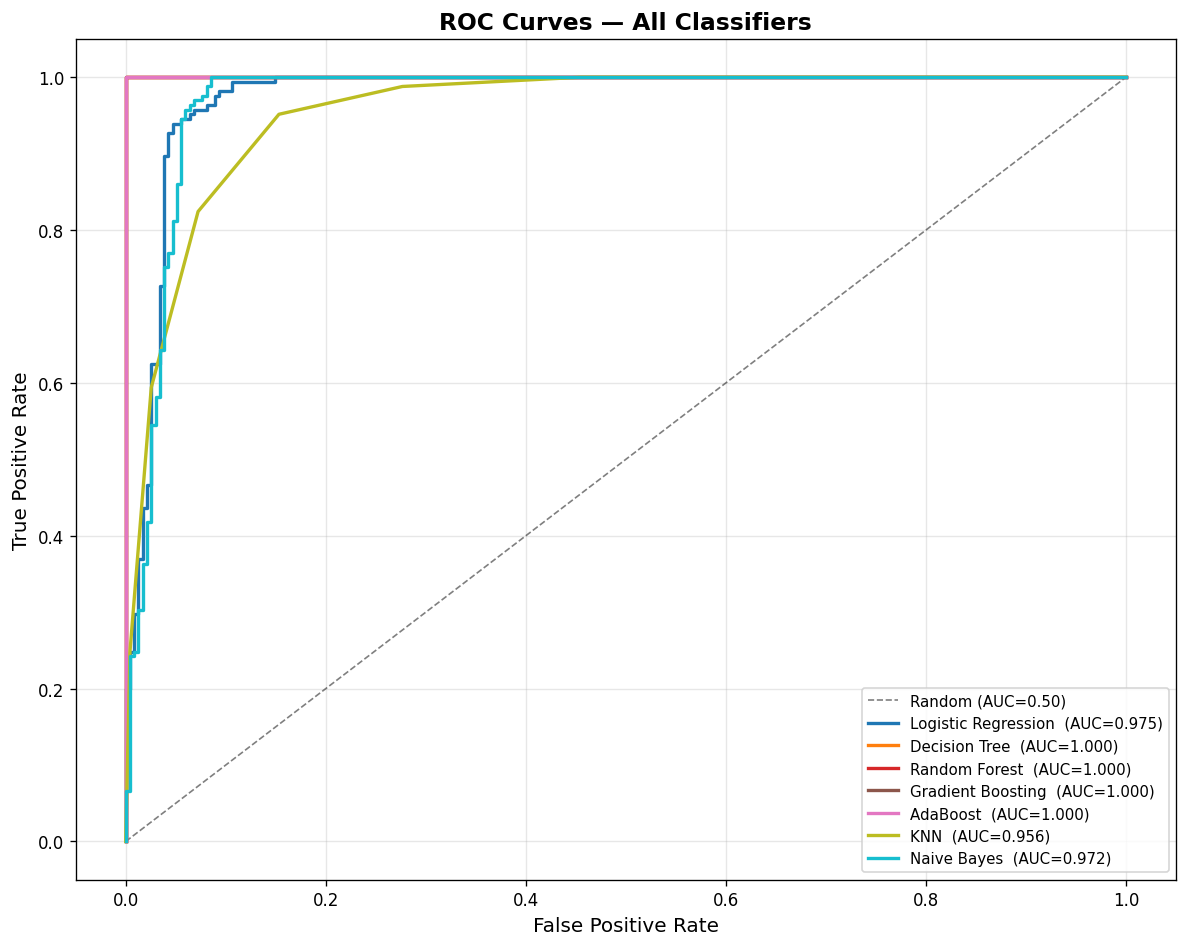

💾 Saved: 12_roc_curves.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.50)')

cmap_roc = plt.cm.get_cmap('tab10', len(trained_models))

for idx, (name, (clf, y_pred, y_proba)) in enumerate(trained_models.items()):
    if y_proba is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, lw=2, color=cmap_roc(idx), label=f'{name}  (AUC={auc:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Classifiers', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loan_viz_output/12_roc_curves.png')
plt.show()
print("💾 Saved: 12_roc_curves.png")


## 17. Confusion Matrices — Top 4 Models

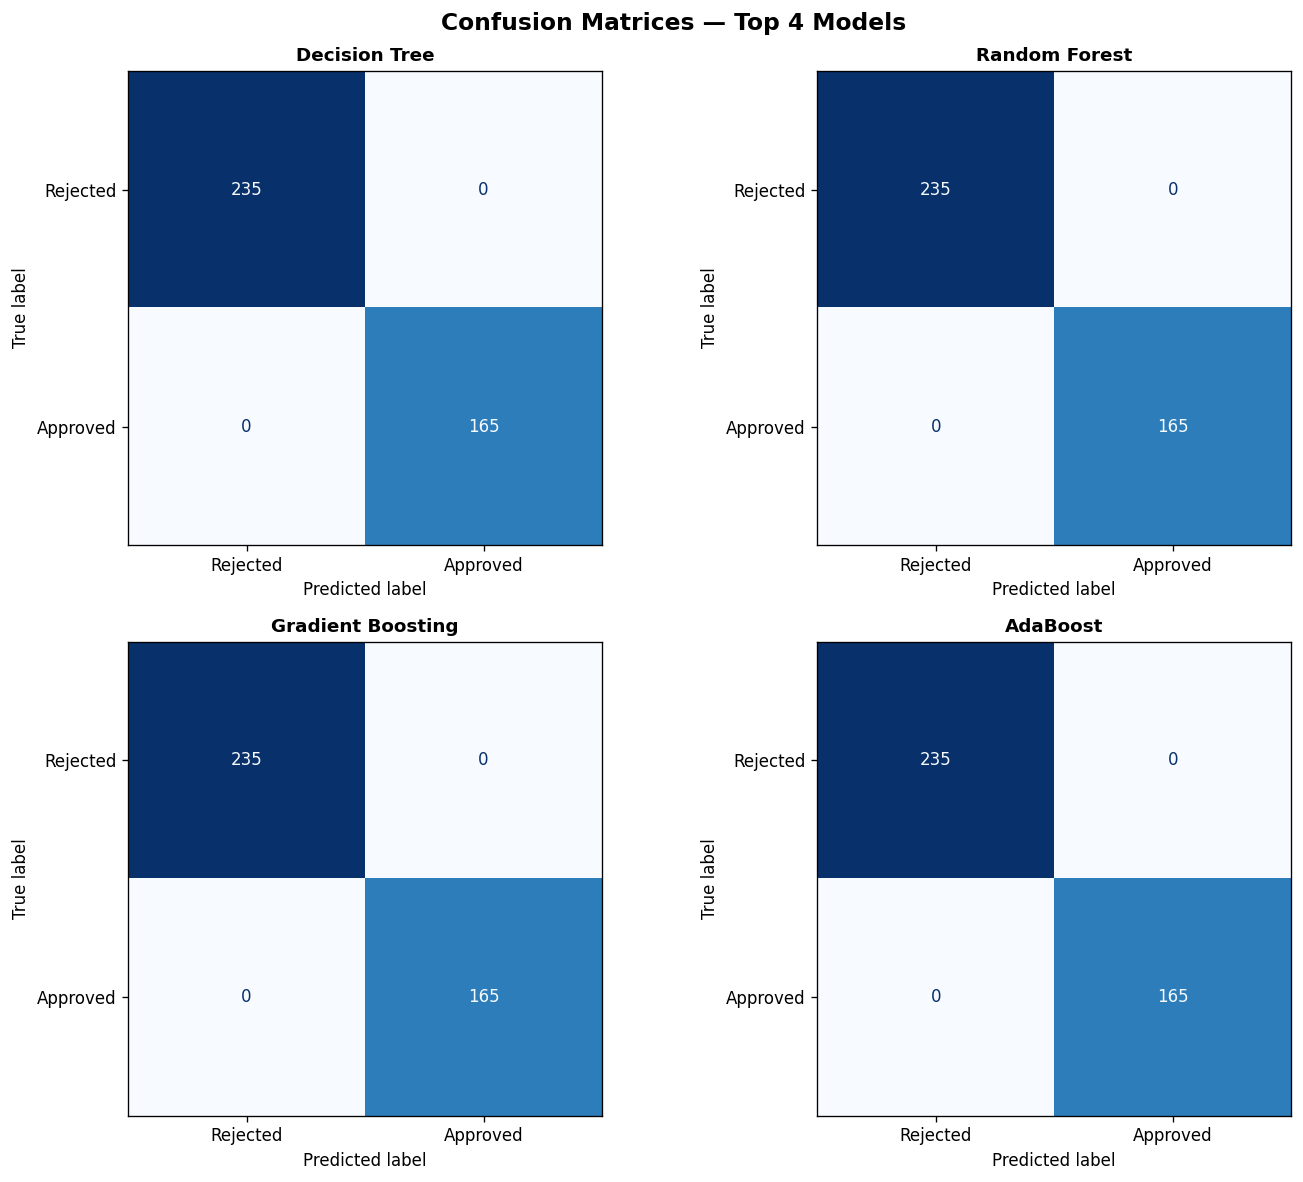

💾 Saved: 13_confusion_matrices.png


In [21]:
top4 = results_df.head(4)['Model'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
fig.suptitle("Confusion Matrices — Top 4 Models", fontsize=14, fontweight='bold')

for ax, name in zip(axes, top4):
    clf, y_pred, _ = trained_models[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('loan_viz_output/13_confusion_matrices.png')
plt.show()
print("💾 Saved: 13_confusion_matrices.png")


## 18. Feature Importance — Random Forest & Gradient Boosting

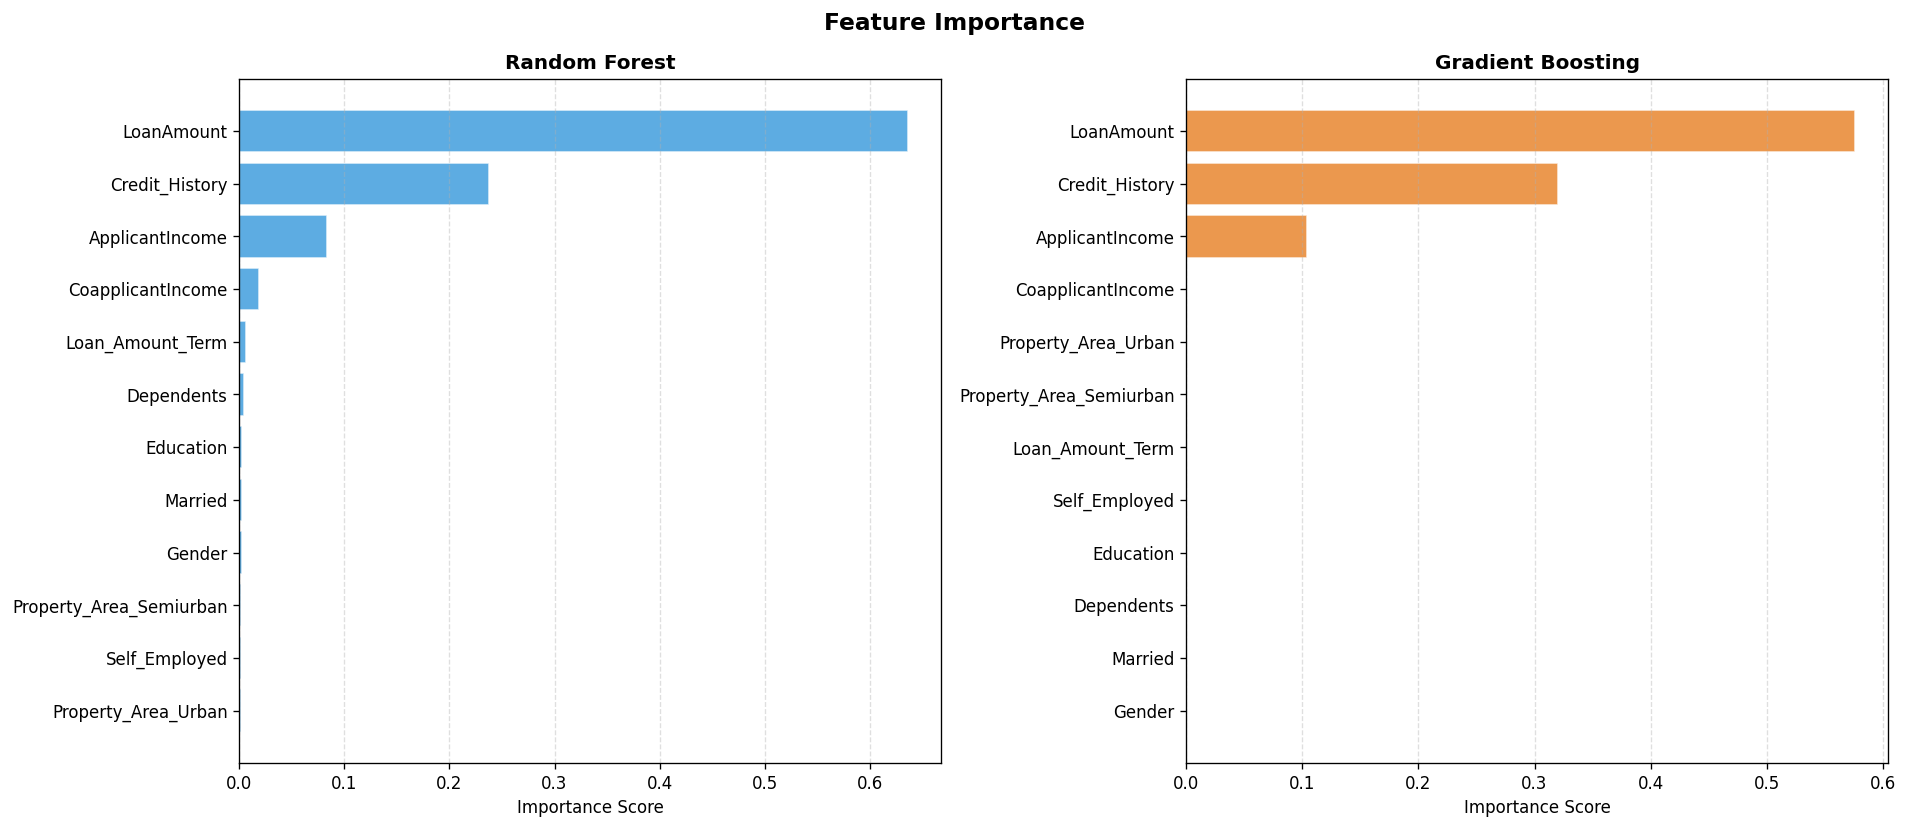

💾 Saved: 14_feature_importance.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Feature Importance", fontsize=14, fontweight='bold')

feature_names = X.columns.tolist()

for ax, mname, color in zip(axes,
                             ['Random Forest', 'Gradient Boosting'],
                             ['#3498db', '#e67e22']):
    clf, _, _ = trained_models[mname]
    importances = clf.feature_importances_
    sorted_idx  = np.argsort(importances)
    ax.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx],
            color=color, alpha=0.8, edgecolor='white')
    ax.set_title(mname, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('loan_viz_output/14_feature_importance.png')
plt.show()
print("💾 Saved: 14_feature_importance.png")


## 19. Radar Chart — Model Performance Profiles

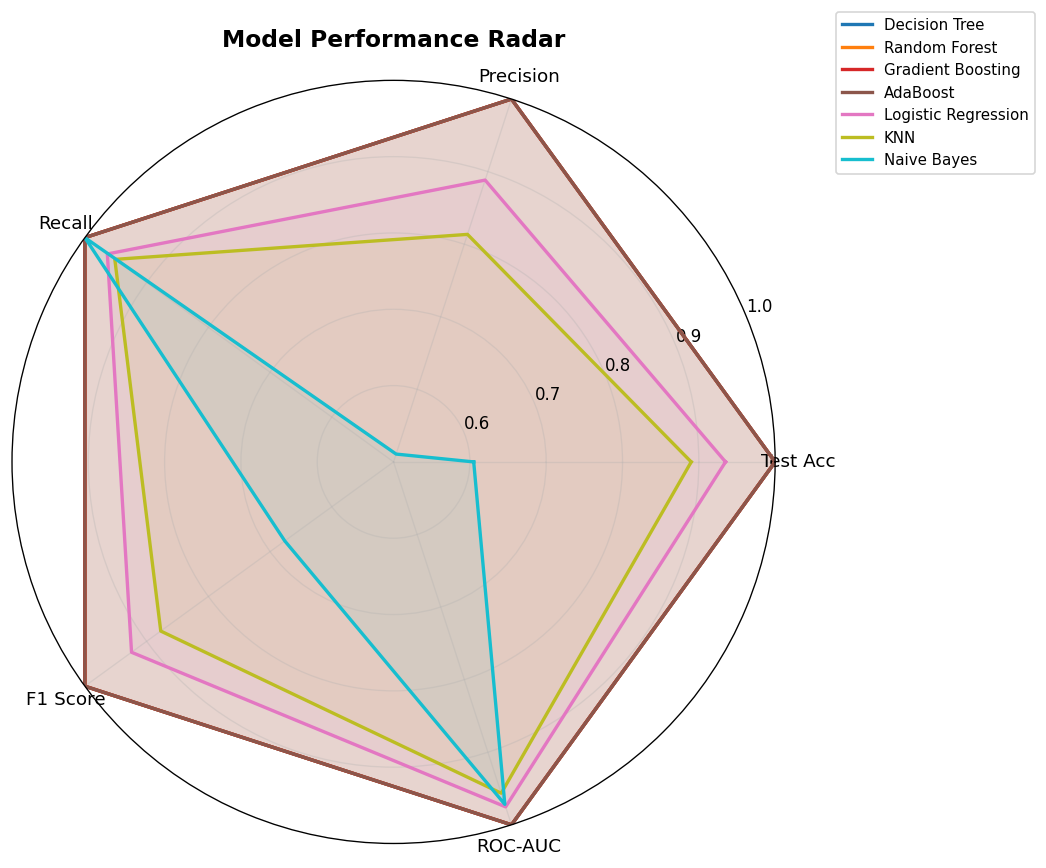

💾 Saved: 15_radar_chart.png


In [23]:
radar_metrics = ['Test Acc', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
radar_df = plot_df.set_index('Model')[radar_metrics].astype(float) / 100

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
cmap_r = plt.cm.get_cmap('tab10', len(radar_df))

for idx, (model_name, row) in enumerate(radar_df.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, lw=2, color=cmap_r(idx), label=model_name)
    ax.fill(angles, values, alpha=0.07, color=cmap_r(idx))

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_title("Model Performance Radar", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loan_viz_output/15_radar_chart.png')
plt.show()
print("💾 Saved: 15_radar_chart.png")


## 20. Best Model — Detailed Classification Report

In [24]:
best_name = results_df.iloc[0]['Model']
clf_best, y_pred_best, y_proba_best = trained_models[best_name]

print(f"🏆 Best Model: {best_name}")
print("=" * 55)
print(classification_report(y_test, y_pred_best, target_names=['Rejected', 'Approved']))


🏆 Best Model: Decision Tree
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       235
    Approved       1.00      1.00      1.00       165

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## 21. Save Metrics Summary & Wrap-Up

In [25]:
results_df.to_csv('loan_viz_output/model_metrics_summary.csv', index=False)
print("💾 Saved: model_viz_output/model_metrics_summary.csv")

saved = sorted(os.listdir('loan_viz_output'))
print(f"\n📁 All outputs saved to ./loan_viz_output/ ({len(saved)} files):")
for f in saved:
    print(f"   {f}")


💾 Saved: model_viz_output/model_metrics_summary.csv

📁 All outputs saved to ./loan_viz_output/ (16 files):
   01_categorical_distributions.png
   02_numerical_distributions.png
   03_approval_by_category.png
   04_income_vs_loanamount_scatter.png
   05_boxplots_by_loan_status.png
   06_violin_income_gender.png
   07_correlation_heatmap.png
   08_pairplot.png
   09_approval_rate_heatmap.png
   10_loan_bucket_approval.png
   11_model_comparison_bar.png
   12_roc_curves.png
   13_confusion_matrices.png
   14_feature_importance.png
   15_radar_chart.png
   model_metrics_summary.csv
